In [10]:
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten



In [ ]:
# Loading  dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Print dataset shapes 
print(f"Training data shape: {x_train.shape}")
print(f"Test data shape: {x_test.shape}")

Training data shape: (60000, 28, 28)
Test data shape: (10000, 28, 28)


In [13]:
# Flatten images
x_train_flat = x_train.reshape(-1, 28*28)
x_test_flat = x_test.reshape(-1, 28*28)

# Normalize pixel by devicing it by 255 
x_train_flat, x_test_flat = x_train_flat / 255.0, x_test_flat / 255.0

# One-hot encode labels
y_train_onehot = to_categorical(y_train, 10)
y_test_onehot = to_categorical(y_test, 10)

#print the shape of the preprocessed data 
print(f"Preprocessed training data shape: {x_train_flat.shape}")
print(f"Preprocessed test data shape: {x_test_flat.shape}")
print(f"One-hot encoded training labels shape: {y_train_onehot.shape}")


Preprocessed training data shape: (60000, 784)
Preprocessed test data shape: (10000, 784)
One-hot encoded training labels shape: (60000, 10)


In [14]:
# Build the Fully Connected Neural Network model

model_fcnn = Sequential([
    Dense(128, activation='relu', input_shape=(28*28,)),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')  # Output layer for 10 classes
])

# Compile the model
model_fcnn.compile(optimizer='adam',
                   loss='categorical_crossentropy',
                   metrics=['accuracy'])

# Train the model
history_fcnn = model_fcnn.fit(x_train_flat, y_train_onehot, epochs=10, validation_data=(x_test_flat, y_test_onehot))

#Evaluate the model on the test data
test_loss, test_acc = model_fcnn.evaluate(x_test_flat, y_test_onehot)
print(f"Test accuracy for Fully Connected Network: {test_acc}")



b:\Learning\DI_Bootcamp\.venv\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.8793 - loss: 0.4196 - val_accuracy: 0.9600 - val_loss: 0.1289
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9674 - loss: 0.1095 - val_accuracy: 0.9698 - val_loss: 0.0971
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.9764 - loss: 0.0756 - val_accuracy: 0.9751 - val_loss: 0.0851
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9826 - loss: 0.0539 - val_accuracy: 0.9725 - val_loss: 0.0920
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9856 - loss: 0.0452 - val_accuracy: 0.9769 - val_loss: 0.0790
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9889 - loss: 0.0330 - val_accuracy: 0.9735 - val_loss: 0.0889
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9914 - loss: 0.0258 - val_accuracy: 0.9773 - val_loss: 0.0888
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9927 - loss: 0.0224 - 

In [15]:
# Reshape the images to include the channel dimension (28x28x1 for grayscale)
x_train_cnn = x_train.reshape(-1, 28, 28, 1)  # Shape (60000, 28, 28, 1)
x_test_cnn = x_test.reshape(-1, 28, 28, 1)    # Shape (10000, 28, 28, 1)

# Normalize pixel values (0-255) -> (0-1)
x_train_cnn = x_train_cnn / 255.0
x_test_cnn = x_test_cnn / 255.0

# One-hot encode the labels (same as for the Fully Connected model)
y_train_cnn = to_categorical(y_train, 10)
y_test_cnn = to_categorical(y_test, 10)

# Print out the shapes of the preprocessed data
print(f"Preprocessed training data shape for CNN: {x_train_cnn.shape}")
print(f"Preprocessed test data shape for CNN: {x_test_cnn.shape}")
print(f"One-hot encoded training labels shape for CNN: {y_train_cnn.shape}")


Preprocessed training data shape for CNN: (60000, 28, 28, 1)
Preprocessed test data shape for CNN: (10000, 28, 28, 1)
One-hot encoded training labels shape for CNN: (60000, 10)


In [ ]:
# Build the Convolutional Neural Network
model_cnn = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),  # Convolutional layer
    tf.keras.layers.MaxPooling2D((2, 2)),  # MaxPooling layer
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),  # Another Convolutional layer
    tf.keras.layers.MaxPooling2D((2, 2)),  # Another MaxPooling layer
    tf.keras.layers.Flatten(),  # Flatten the 2D output into 1D
    tf.keras.layers.Dense(128, activation='relu'),  # Fully connected hidden layer
    tf.keras.layers.Dense(10, activation='softmax')  # Output layer with 10 classes
])

# Compile the model
model_cnn.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

# Train the model
history_cnn = model_cnn.fit(x_train_cnn, y_train_cnn, epochs=10, validation_data=(x_test_cnn, y_test_cnn))

# Evaluate the model on the test data
test_loss_cnn, test_acc_cnn = model_cnn.evaluate(x_test_cnn, y_test_cnn)
print(f"Test accuracy for CNN: {test_acc_cnn}")


b:\Learning\DI_Bootcamp\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.9096 - loss: 0.2910 - val_accuracy: 0.9832 - val_loss: 0.0462
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.9870 - loss: 0.0424 - val_accuracy: 0.9900 - val_loss: 0.0310
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.9899 - loss: 0.0291 - val_accuracy: 0.9896 - val_loss: 0.0338
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.9941 - loss: 0.0196 - val_accuracy: 0.9892 - val_loss: 0.0346
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.9953 - loss: 0.0142 - val_accuracy: 0.9918 - val_loss: 0.0259
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.9967 - loss: 0.0105 - val_accuracy: 0.9914 - val_loss: 0.0289
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.9973 - loss: 0.0091 - val_accuracy: 0.9918 - val_loss: 0.0285
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.9979 - loss: 0

In [18]:
# Evaluate the Fully Connected Neural Network
test_loss_fcnn, test_acc_fcnn = model_fcnn.evaluate(x_test_flat, y_test_onehot)
print(f"FCNN Test accuracy: {test_acc_fcnn}")

# Evaluate the Convolutional Neural Network
test_loss_cnn, test_acc_cnn = model_cnn.evaluate(x_test_cnn, y_test_onehot)
print(f"CNN Test accuracy: {test_acc_cnn}")


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9739 - loss: 0.1054
FCNN Test accuracy: 0.977400004863739
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9890 - loss: 0.0514
CNN Test accuracy: 0.9909999966621399


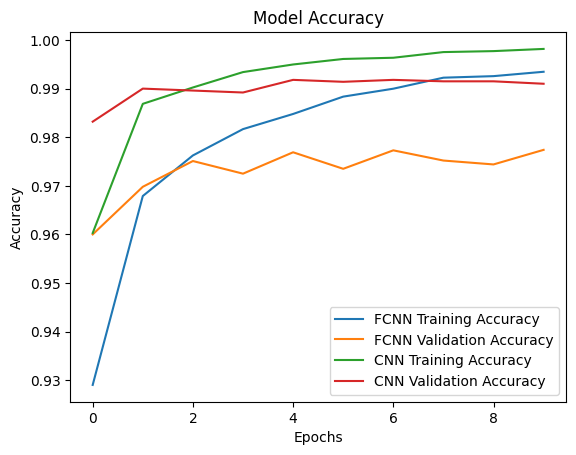

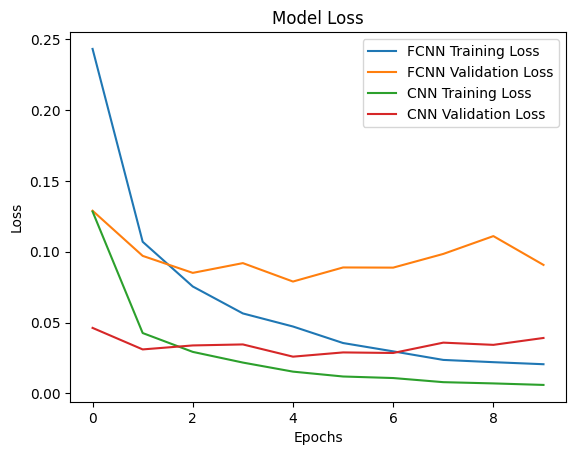

In [19]:
# Plot accuracy
plt.plot(history_fcnn.history['accuracy'], label='FCNN Training Accuracy')
plt.plot(history_fcnn.history['val_accuracy'], label='FCNN Validation Accuracy')
plt.plot(history_cnn.history['accuracy'], label='CNN Training Accuracy')
plt.plot(history_cnn.history['val_accuracy'], label='CNN Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot loss
plt.plot(history_fcnn.history['loss'], label='FCNN Training Loss')
plt.plot(history_fcnn.history['val_loss'], label='FCNN Validation Loss')
plt.plot(history_cnn.history['loss'], label='CNN Training Loss')
plt.plot(history_cnn.history['val_loss'], label='CNN Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()
